In [6]:
import numpy as np
import pandas as pd
import torch as t
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM,
    AutoTokenizer,
    DataCollatorWithPadding,
    pipeline
)
import matplotlib.pyplot as plt
import seaborn as sns
import configparser

#plt.style.use('default')
#style.use('seaborn-dark')
#import plotly.io as pio
#pio.templates.default = "ggplot2" #ggplot2, plotly_dark

MODEL_PATH = "./final_model"

In [4]:
import shap
shap.initjs()

In [14]:
model_name = "roberta-non-knowledge-v1"
config = configparser.ConfigParser()
config.read('config.ini')
MODEL_PATH = config[model_name]['weights_directory']
#AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, truncation=True, max_length=512)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    torch_dtype=t.bfloat16,
    device_map="mps"
)

# def predict_proba(texts):
#     """Predict probability for binary classification"""
#     inputs = tokenizer(
#         texts,
#         truncation=True,
#         max_length=512,
#         padding=True,
#         return_tensors="pt"
#     )
    
#     with t.no_grad():
#         inputs = {k: v.to("mps") for k, v in inputs.items()}
#         outputs = model(**inputs)
#         probs = t.softmax(outputs.logits, dim=-1).cpu().float()
    
#     # Return only Knowledge (0) and Non-Knowledge (2) probabilities
#     return probs[:, [0, 2]].numpy()

pred = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device_map="mps",
    return_all_scores=True,
)

Device set to use mps


In [17]:
TEXT = """
This is not a major issue because long running migrations are so infrequently run, but just wanted to call it out.

openVoxDB will bind its port during startup, but before migrations are run, but it will reject all queries until 
migrations are finished. So I think this will report the service as ready before it can respond to queries. This 
may be a problem for catalog applications that apply a long running migration where subsequent resources Require 
the db service and expect to be able to query it.
"""

In [12]:
TEXT = """
On the surface, it seems like ctx.unwrap_tensors() (with ctx being a PythonFunctionalizeAPI in this case) is not smart enough to handle tensor subclasses? Should it be handled there or more ad-hoc within flex_attention's impl?
"""

In [16]:
test_df = pd.read_csv("datasets/OpenVox_non_knowledge_eval.csv")

binary_df = test_df[test_df['final_label'].isin([0, 2])].copy()
#binary_df = binary_df.sample(n=min(n_samples, len(binary_df)), random_state=42)
binary_df = pd.DataFrame({"statement": binary_df["statement"], "final_label": binary_df["final_label"]})
#texts = binary_df['statement'].tolist()
#true_labels = binary_df['final_label'].tolist()

explainer = shap.Explainer(pred, tokenizer)
#binary_df.head()
shap_values = explainer(binary_df["statement"])
#shap_values = explainer([TEXT])

PartitionExplainer explainer:  71%|███████   | 17/24 [01:08<00:28,  4.10s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 25it [01:39,  4.51s/it]                        


In [17]:
shap.plots.text(shap_values[0])
#force_plot = shap.force_plot(explainer.expected_value, shap_values[0], matplotlib=True)
# HTML(f"<div style='background-color:white;'>{shap.getjs() + force_plot.html()}</div>")

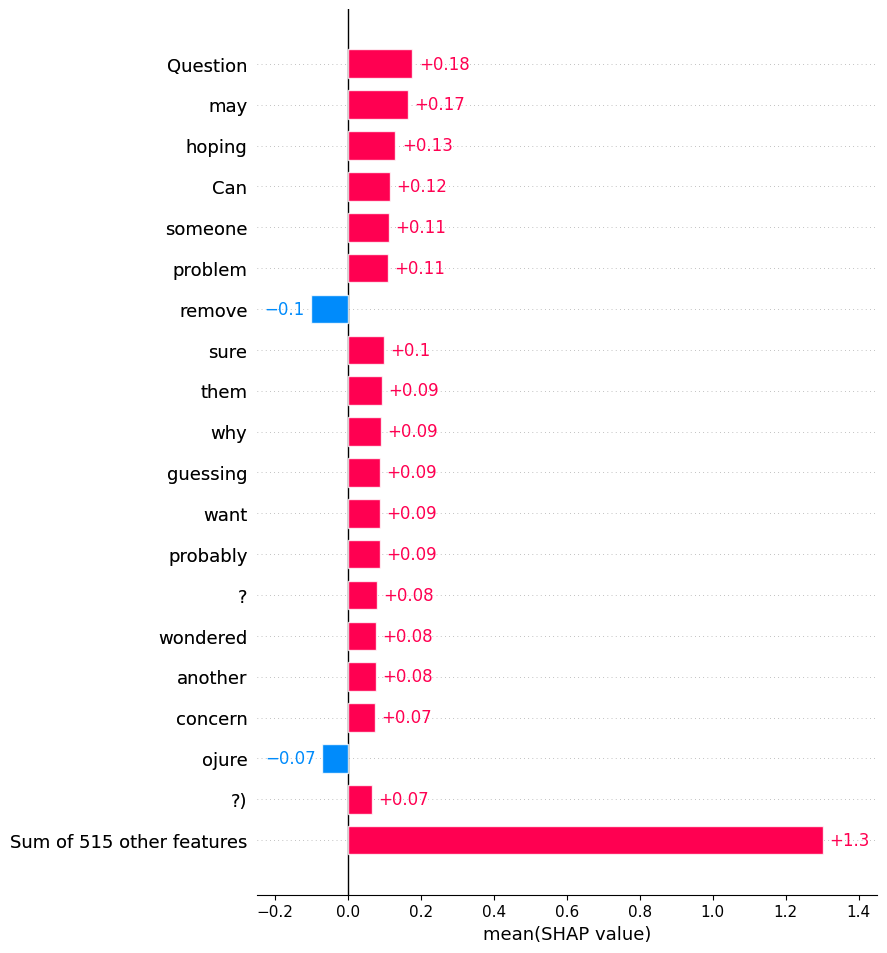

In [22]:
shap.plots.bar(shap_values[:, :, 2].mean(0), max_display=20)

In [ ]:
for i in range(min(3, len(texts))):
    plt.figure(figsize=(12, 4))
    shap.plots.text(shap_values[i, :, 1], display=False)  # Class index 1 = Non-Knowledge (label 2)
    plt.show()

In [ ]:
def shap_analysis_binary(self, n_samples=100):
        """
        SHAP analysis for binary classification (Knowledge vs Non-Knowledge)
        Ignoring Neutral class for interpretability
        Note: Knowledge=0, Non-Knowledge=2
        """
        logger.info("Starting SHAP analysis (binary: Knowledge vs Non-Knowledge)...")
        
        # Filter dataset to only Knowledge (0) and Non-Knowledge (2)
        binary_df = self.test_df[self.test_df['final_label'].isin([0, 2])].copy()
        binary_df = binary_df.sample(n=min(n_samples, len(binary_df)), random_state=42)
        
        texts = binary_df['statement'].tolist()
        true_labels = binary_df['final_label'].tolist()
        
        # Create prediction function for SHAP
        def predict_proba(texts):
            """Predict probability for binary classification"""
            inputs = self.tokenizer(
                texts,
                truncation=True,
                max_length=512,
                padding=True,
                return_tensors="pt"
            )
            
            with t.no_grad():
                inputs = {k: v.to(self.device) for k, v in inputs.items()}
                outputs = self.model(**inputs)
                probs = t.softmax(outputs.logits, dim=-1).cpu().numpy()
            
            # Return only Knowledge (0) and Non-Knowledge (2) probabilities
            return probs[:, [0, 2]]
        
        # Create SHAP explainer
        logger.info("Creating SHAP explainer (this may take a while)...")
        explainer = shap.Explainer(predict_proba, self.tokenizer)
        
        # Compute SHAP values for sample texts
        logger.info(f"Computing SHAP values for {len(texts)} samples...")
        shap_values = explainer(texts[:20])  # Limit to 20 for visualization
        
        # Text plot for first few examples
        print("\n" + "="*60)
        print("SHAP ANALYSIS - BINARY CLASSIFICATION")
        print("="*60)
        
        # Save visualizations
        logger.info("Generating SHAP visualizations...")
        
        # Text plot for individual predictions
        for i in range(min(3, len(texts))):
            plt.figure(figsize=(12, 4))
            shap.plots.text(shap_values[i, :, 1], display=False)  # Class index 1 = Non-Knowledge (label 2)
            plt.savefig(f'shap_text_example_{i}.png', dpi=300, bbox_inches='tight')
            plt.close()
            logger.info(f"Saved SHAP text plot {i}")
        
        # Bar plot showing mean absolute SHAP values
        plt.figure(figsize=(12, 6))
        shap.plots.bar(shap_values[:, :, 1], max_display=20, show=False)  # Non-Knowledge direction
        plt.tight_layout()
        plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
        plt.close()
        logger.info("Saved SHAP bar plot")
        
        # Beeswarm plot
        plt.figure(figsize=(12, 8))
        shap.plots.beeswarm(shap_values[:, :, 1], max_display=20, show=False)  # Non-Knowledge direction
        plt.tight_layout()
        plt.savefig('shap_beeswarm_plot.png', dpi=300, bbox_inches='tight')
        plt.close()
        logger.info("Saved SHAP beeswarm plot")
        
        logger.info("SHAP analysis complete!")
        
        return shap_values
    